In [4]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv('dataset.csv')
df

,name,chain,type,seat,location,menu items,rate,telephone
0,shila,True,Restaurant,50,1,59,4.7,88862491
1,land,True,Pizza,40,1,45,4.3,88215242
2,naam,False,Café,30,0,20,4.0,88922948
3,noon,True,Café,15,1,15,5.0,38449276
4,shabdiz,True,Restaurant,100,1,42,4.9,38666666
5,neyshekar,True,Pastry,0,1,8,4.0,3724 1053
6,naan reza,False,Bakery,0,0,3,4.0,32259269
7,chorak amin,False,Bakery,0,0,10,4.5,3876 2200
8,iran burger,NaN,Fast Food,20,1,40,4.7,3603 1616


In [6]:
df.head()

,name,chain,type,seat,location,menu items,rate,telephone
0,shila,True,Restaurant,50,1,59,4.7,88862491
1,land,True,Pizza,40,1,45,4.3,88215242
2,naam,False,Café,30,0,20,4.0,88922948
3,noon,True,Café,15,1,15,5.0,38449276
4,shabdiz,True,Restaurant,100,1,42,4.9,38666666


In [7]:
df.tail()

,name,chain,type,seat,location,menu items,rate,telephone
4,shabdiz,True,Restaurant,100,1,42,4.9,38666666
5,neyshekar,True,Pastry,0,1,8,4.0,3724 1053
6,naan reza,False,Bakery,0,0,3,4.0,32259269
7,chorak amin,False,Bakery,0,0,10,4.5,3876 2200
8,iran burger,NaN,Fast Food,20,1,40,4.7,3603 1616


In [9]:
df.shape

(9, 8)

In [13]:
df.drop(['rate'], axis = 1, inplace = True)

In [15]:
df.columns

Index(['name', 'chain', 'type', 'seat', 'location', 'menu items', 'telephone'], dtype='object')

In [16]:
df['name']

0          shila
1           land
2           naam
3           noon
4        shabdiz
5      neyshekar
6      naan reza
7    chorak amin
8    iran burger
Name: name, dtype: object

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        9 non-null      object
 1   chain       8 non-null      object
 2   type        9 non-null      object
 3   seat        9 non-null      int64 
 4   location    9 non-null      int64 
 5   menu items  9 non-null      int64 
 6   telephone   9 non-null      object
dtypes: int64(3), object(4)
memory usage: 636.0+ bytes


In [19]:
df[df['chain'].isnull()]

,name,chain,type,seat,location,menu items,telephone
8,iran burger,NaN,Fast Food,20,1,40,3603 1616


In [20]:
df['name'].unique()

array(['shila', 'land', 'naam', 'noon', 'shabdiz', 'neyshekar',
       'naan reza', 'chorak amin', 'iran burger'], dtype=object)

In [26]:
df['chain'].value_counts()

chain
True     6
False    3
Name: count, dtype: int64

In [25]:
df['chain'].fillna(True, inplace=True)

In [27]:
df['chain'].isnull().sum()

np.int64(0)

In [28]:
df.drop_duplicates(inplace=True)

In [29]:
Business_count = df['type'].value_counts()
Business_count

type
Restaurant    2
Café          2
Bakery        2
Pizza         1
Pastry        1
Fast Food     1
Name: count, dtype: int64

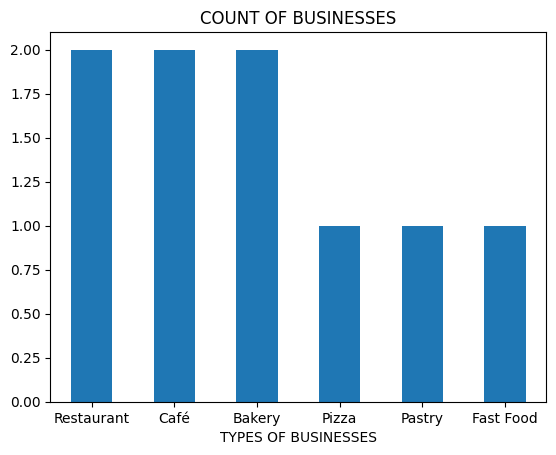

In [31]:
Business_count.plot(kind='bar', rot=0)

plt.xlabel("TYPES OF BUSINESSES")
plt.title("COUNT OF BUSINESSES")

plt.show()

In [32]:
Chain_count = df['chain'].value_counts()
Chain_count

chain
True     6
False    3
Name: count, dtype: int64

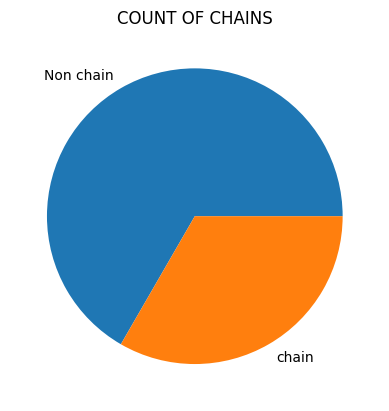

In [37]:
fig, ax = plt.subplots(facecolor='white')
ax.pie(Chain_count, labels=['Non chain', 'chain'])

plt.title("COUNT OF CHAINS")
plt.show()

In [40]:
chain = df.groupby(['type', 'chain'])['chain'].count().sort_values()
chain

type        chain
Café        False    1
            True     1
Fast Food   True     1
Pastry      True     1
Pizza       True     1
Bakery      False    2
Restaurant  True     2
Name: chain, dtype: int64

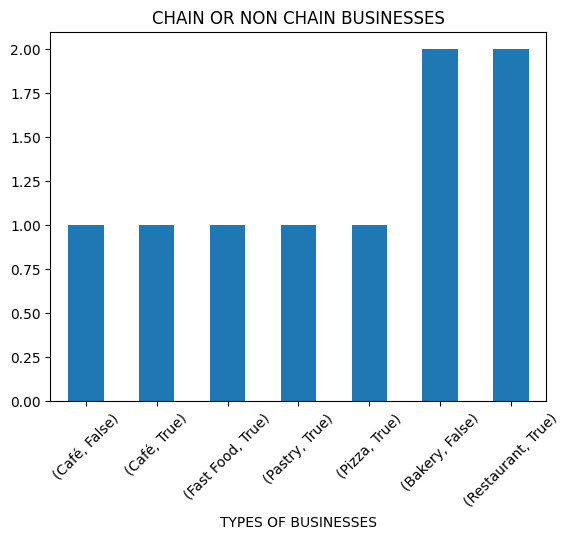

In [43]:
chain.plot(kind='bar', rot=45)

plt.xlabel("TYPES OF BUSINESSES")
plt.title("CHAIN OR NON CHAIN BUSINESSES")

plt.show()

In [44]:
is_chain = df[df['chain'] == True]
is_chain

,name,chain,type,seat,location,menu items,telephone
0,shila,True,Restaurant,50,1,59,88862491
1,land,True,Pizza,40,1,45,88215242
3,noon,True,Café,15,1,15,38449276
4,shabdiz,True,Restaurant,100,1,42,38666666
5,neyshekar,True,Pastry,0,1,8,3724 1053
8,iran burger,True,Fast Food,20,1,40,3603 1616


In [45]:
print(is_chain['seat'].describe())

count      6.000000
mean      37.500000
std       35.461246
min        0.000000
25%       16.250000
50%       30.000000
75%       47.500000
max      100.000000
Name: seat, dtype: float64


In [48]:
df['location'].value_counts()


location
1    6
0    3
Name: count, dtype: int64

In [53]:
df['menu items'].mean()

np.float64(26.88888888888889)

In [55]:
menuitem = df[df['menu items'] > 25]
menuitem['type'].value_counts()

type
Restaurant    2
Pizza         1
Fast Food     1
Name: count, dtype: int64

In [56]:
menu = menuitem['menu items'].value_counts()
menu

menu items
59    1
45    1
42    1
40    1
Name: count, dtype: int64

In [70]:
def f(x):
    if x < 42:
        return 'few'
    else:
        return 'many'

In [71]:
menuitem['menu'] = menuitem['menu items'].apply(f)
menuitem

C:\Users\Ala\AppData\Local\Temp\ipykernel_376\748755816.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  menuitem['menu'] = menuitem['menu items'].apply(f)


,name,chain,type,seat,location,menu items,telephone,menu
0,shila,True,Restaurant,50,1,59,88862491,many
1,land,True,Pizza,40,1,45,88215242,many
4,shabdiz,True,Restaurant,100,1,42,38666666,many
8,iran burger,True,Fast Food,20,1,40,3603 1616,few


In [72]:
menu_group = menuitem['menu'].value_counts()
menu_group

menu
many    3
few     1
Name: count, dtype: int64

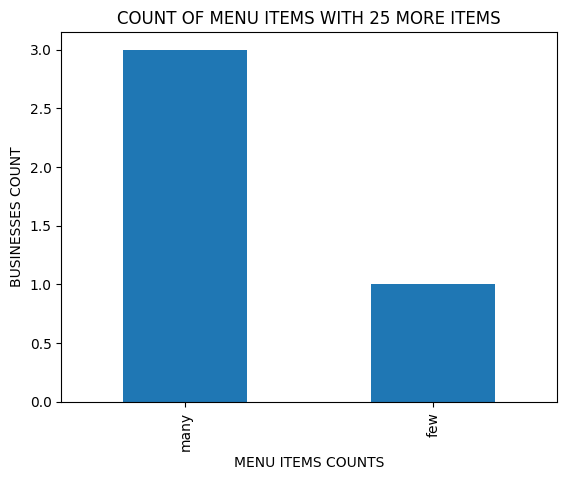

In [73]:
menu_group.plot(kind='bar')

plt.xlabel("MENU ITEMS COUNTS")
plt.ylabel("BUSINESSES COUNT")
plt.title("COUNT OF MENU ITEMS WITH 25 MORE ITEMS")

plt.show()